# 5-Word Sentence Reconstruction Transformer
## Twenty-Epoch Training Diagnostics â€” Seed 42 Only

This notebook reads the saved training history and presents the model's learning behaviour. It does not retrain or evaluate the test set.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter
from IPython.display import HTML, Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'config.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from config import get_config
SEED = 42
config = get_config()
assert config['seed'] == SEED, f"Expected seed {SEED}, found seed {config['seed']}"
EXPERIMENT_ROOT = Path(config['experiment_root'])
HISTORY_PATH = Path(config['training_history_file'])
history = json.loads(HISTORY_PATH.read_text(encoding='utf-8'))
assert len(history) == 20, f'Expected 20 completed epochs, found {len(history)}'

epochs = [int(row['epoch']) + 1 for row in history]
train_loss = [float(row['training_loss']) for row in history]
validation_loss = [float(row['validation_loss']) for row in history]
exact_accuracy = [float(row['exact_match_accuracy']) for row in history]
position_accuracy = [float(row['word_position_accuracy']) for row in history]
validity = [float(row['output_validity_rate']) for row in history]
preservation = [float(row['input_word_preservation_rate']) for row in history]
generalization_gap = [v - t for t, v in zip(train_loss, validation_loss)]
best_index = max(range(len(history)), key=lambda i: (exact_accuracy[i], -validation_loss[i]))
seed_label = f'Seed {SEED}'

COLORS = {'navy': '#183B56', 'blue': '#2F80ED', 'teal': '#00A6A6', 'orange': '#F2994A', 'red': '#D64550', 'grid': '#DCE6EF'}
plt.rcParams.update({'figure.figsize': (11, 6), 'axes.titlesize': 16, 'axes.titleweight': 'bold', 'axes.labelsize': 11, 'font.size': 10})

def finish_plot(ax, percent=False):
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis='y', color=COLORS['grid'], alpha=0.8)
    ax.set_axisbelow(True)
    if percent:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout()

print(f'Loaded {len(history)} completed epochs for {seed_label} from {HISTORY_PATH}')

Loaded 20 completed epochs for Seed 42 from C:\Users\Shushant\Documents\ChatGPT\Whole transfoirmer\accuracy_research_project\experiments\permutations_4581_grouped_epoch7\training_history.json


## Experiment overview

In [2]:
latest = history[-1]
cards = f'''
<div style="display:grid;grid-template-columns:repeat(5,1fr);gap:14px;margin:12px 0 22px 0">
  <div style="background:#F4ECF7;padding:18px;border-radius:12px;border-left:5px solid #7D3C98"><b>Random seed</b><br><span style="font-size:28px">{SEED}</span></div>
  <div style="background:#EAF2F8;padding:18px;border-radius:12px;border-left:5px solid #183B56"><b>Completed epochs</b><br><span style="font-size:28px">{len(history)}</span></div>
  <div style="background:#E8F8F5;padding:18px;border-radius:12px;border-left:5px solid #00A6A6"><b>Best exact match</b><br><span style="font-size:28px">{exact_accuracy[best_index]:.2%}</span><br>Epoch {epochs[best_index]}</div>
  <div style="background:#FEF5E7;padding:18px;border-radius:12px;border-left:5px solid #F2994A"><b>Final train loss</b><br><span style="font-size:28px">{train_loss[-1]:.4f}</span></div>
  <div style="background:#FDEDEC;padding:18px;border-radius:12px;border-left:5px solid #D64550"><b>Final validation loss</b><br><span style="font-size:28px">{validation_loss[-1]:.4f}</span></div>
</div>
'''
display(HTML(cards))

In [3]:
rows = []
for i, row in enumerate(history):
    highlight = ' style="background:#E8F8F5;font-weight:bold"' if i == best_index else ''
    rows.append(f"<tr{highlight}><td>{epochs[i]}</td><td>{train_loss[i]:.4f}</td><td>{validation_loss[i]:.4f}</td><td>{exact_accuracy[i]:.2%}</td><td>{position_accuracy[i]:.2%}</td><td>{generalization_gap[i]:.4f}</td></tr>")
table = '''<table style="border-collapse:collapse;width:100%;text-align:center"><thead><tr style="background:#183B56;color:white"><th>Epoch</th><th>Training loss</th><th>Validation loss</th><th>Exact match</th><th>Word position</th><th>Loss gap</th></tr></thead><tbody>''' + ''.join(rows) + '</tbody></table>'
display(HTML(table))
display(Markdown(f'*Seed {SEED} only. The highlighted row is the best epoch selected by validation exact-match accuracy.*'))

Epoch,Training loss,Validation loss,Exact match,Word position,Loss gap
1,3.1231,2.3495,48.55%,67.83%,-0.7736
2,1.4478,2.2348,52.95%,70.65%,0.7870
3,1.2994,2.2513,54.26%,71.36%,0.9519
4,1.2489,2.2508,53.12%,70.28%,1.0019
5,1.2242,2.2468,53.64%,70.42%,1.0226
6,1.2099,2.2695,54.37%,70.63%,1.0596
7,1.2004,2.2871,53.16%,70.53%,1.0867
8,1.1937,2.2665,55.41%,71.86%,1.0728
9,1.1888,2.2969,54.20%,71.24%,1.1081
10,1.1852,2.2916,54.58%,71.30%,1.1064


*Seed 42 only. The highlighted row is the best epoch selected by validation exact-match accuracy.*

## 1. Training and validation loss

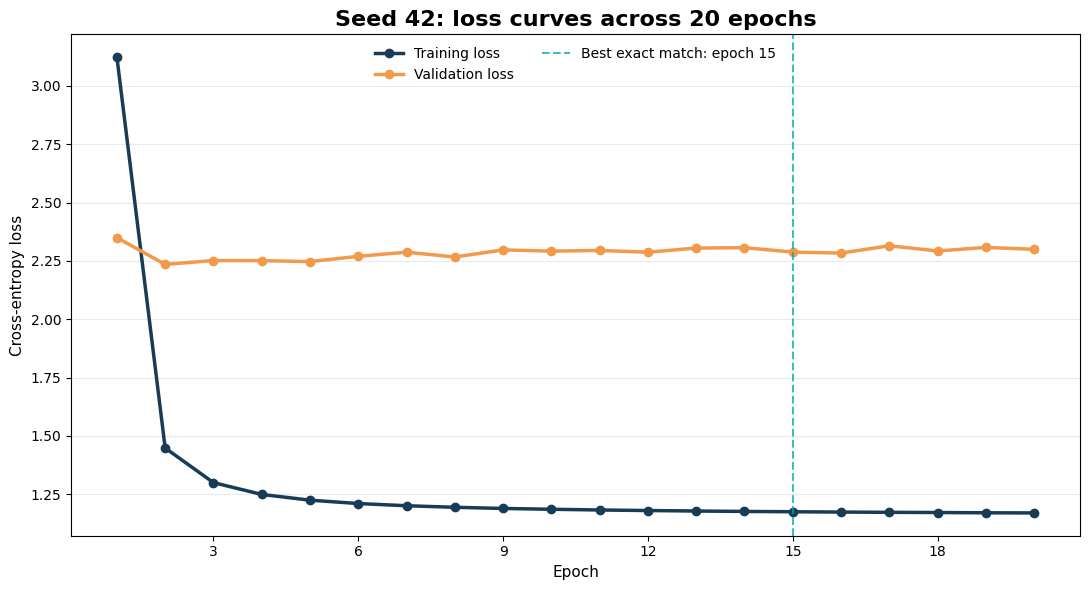

In [4]:
fig, ax = plt.subplots()
ax.plot(epochs, train_loss, marker='o', linewidth=2.5, color=COLORS['navy'], label='Training loss')
ax.plot(epochs, validation_loss, marker='o', linewidth=2.5, color=COLORS['orange'], label='Validation loss')
ax.axvline(epochs[best_index], color=COLORS['teal'], linestyle='--', alpha=.75, label=f'Best exact match: epoch {epochs[best_index]}')
ax.set(title=f'{seed_label}: loss curves across 20 epochs', xlabel='Epoch', ylabel='Cross-entropy loss')
finish_plot(ax)
plt.show()

## 2. Validation accuracy

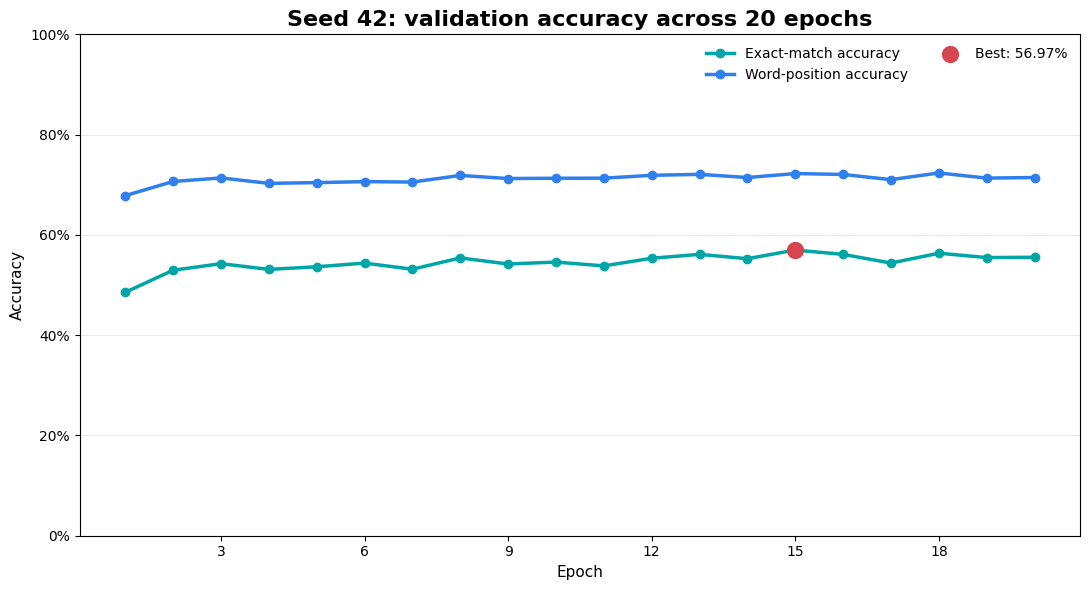

In [5]:
fig, ax = plt.subplots()
ax.plot(epochs, exact_accuracy, marker='o', linewidth=2.5, color=COLORS['teal'], label='Exact-match accuracy')
ax.plot(epochs, position_accuracy, marker='o', linewidth=2.5, color=COLORS['blue'], label='Word-position accuracy')
ax.scatter(epochs[best_index], exact_accuracy[best_index], s=130, color=COLORS['red'], zorder=5, label=f'Best: {exact_accuracy[best_index]:.2%}')
ax.set(title=f'{seed_label}: validation accuracy across 20 epochs', xlabel='Epoch', ylabel='Accuracy', ylim=(0, 1))
finish_plot(ax, percent=True)
plt.show()

## 3. Generalization gap

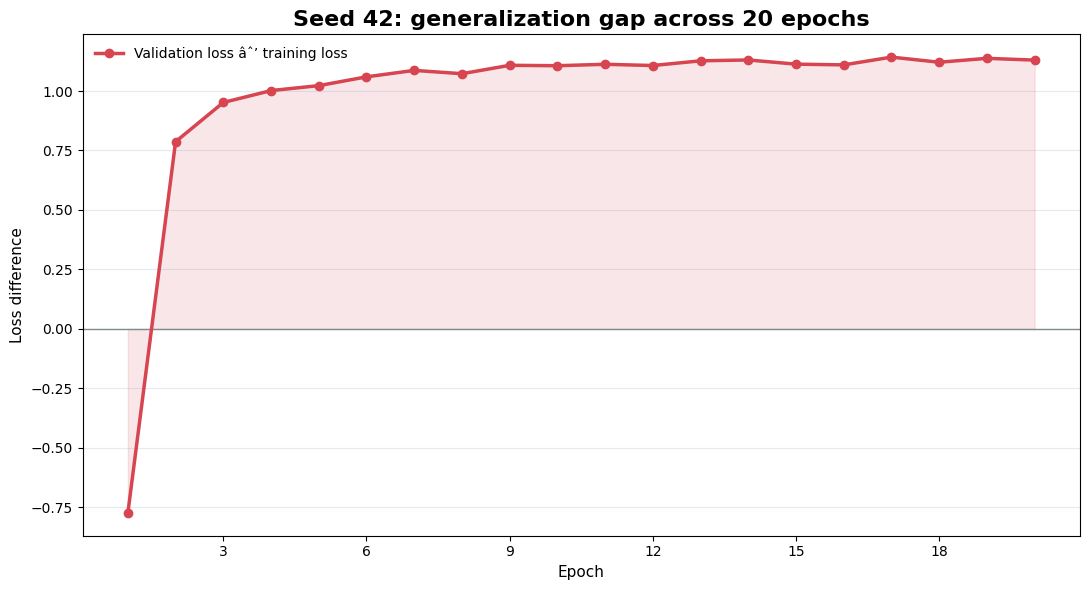

In [6]:
fig, ax = plt.subplots()
ax.axhline(0, color='#7F8C8D', linewidth=1)
ax.plot(epochs, generalization_gap, marker='o', linewidth=2.5, color=COLORS['red'], label='Validation loss âˆ’ training loss')
ax.fill_between(epochs, 0, generalization_gap, color=COLORS['red'], alpha=.13)
ax.set(title=f'{seed_label}: generalization gap across 20 epochs', xlabel='Epoch', ylabel='Loss difference')
finish_plot(ax)
plt.show()

## 4. Output constraints

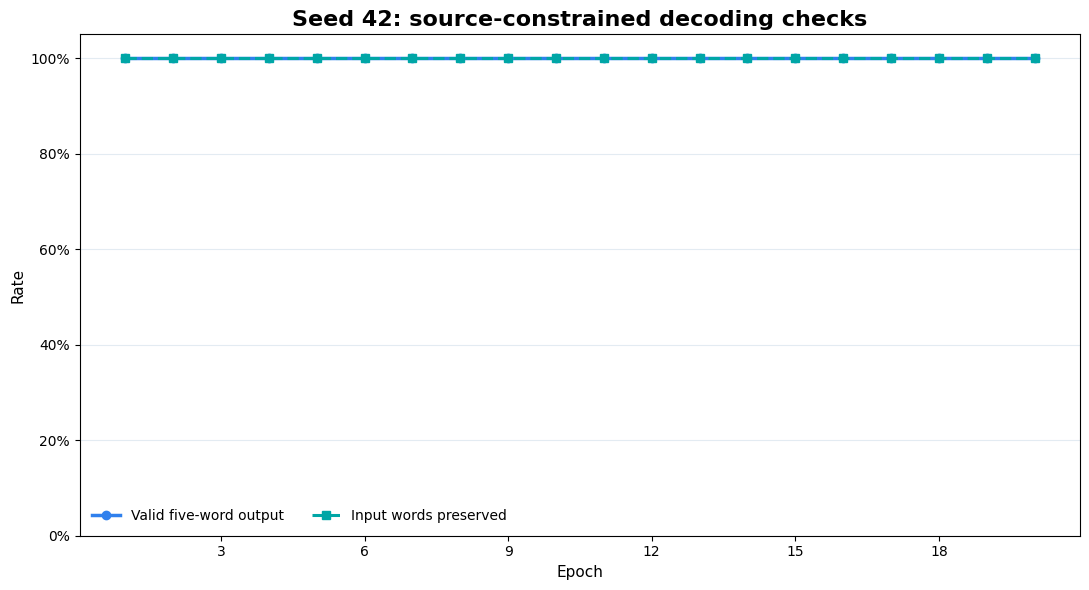

In [7]:
fig, ax = plt.subplots()
ax.plot(epochs, validity, marker='o', linewidth=2.5, color=COLORS['blue'], label='Valid five-word output')
ax.plot(epochs, preservation, marker='s', linewidth=2.2, linestyle='--', color=COLORS['teal'], label='Input words preserved')
ax.set(title=f'{seed_label}: source-constrained decoding checks', xlabel='Epoch', ylabel='Rate', ylim=(0, 1.05))
finish_plot(ax, percent=True)
plt.show()

## Interpretation

In [8]:
interpretation = f'''
**Results below are for seed {SEED} only.**

- Training loss fell from **{train_loss[0]:.4f}** to **{train_loss[-1]:.4f}**, so the model learned the training patterns.
- The best validation exact-match accuracy was **{exact_accuracy[best_index]:.2%} at epoch {epochs[best_index]}**.
- Final validation exact-match accuracy was **{exact_accuracy[-1]:.2%}** and final word-position accuracy was **{position_accuracy[-1]:.2%}**.
- Validation loss stopped improving while training loss continued to fall. The widening loss gap is evidence of **overfitting / diminishing returns from additional epochs**.
- These curves diagnose training behaviour, but they cannot alone prove that either the architecture or dataset is the sole cause. A proper dataset-size learning curveâ€”training identical models on increasing numbers of unique base sentencesâ€”is needed to separate insufficient data from insufficient model capacity.
- The 100% constraint curves mean every decoded result had five words and preserved the input words. They do **not** mean that the word order was correct.
- Model selection must use validation results. The test set should remain reserved for the final, one-time evaluation of the selected checkpoint.
'''
display(Markdown(interpretation))


**Results below are for seed 42 only.**

- Training loss fell from **3.1231** to **1.1696**, so the model learned the training patterns.
- The best validation exact-match accuracy was **56.97% at epoch 15**.
- Final validation exact-match accuracy was **55.53%** and final word-position accuracy was **71.44%**.
- Validation loss stopped improving while training loss continued to fall. The widening loss gap is evidence of **overfitting / diminishing returns from additional epochs**.
- These curves diagnose training behaviour, but they cannot alone prove that either the architecture or dataset is the sole cause. A proper dataset-size learning curveâ€”training identical models on increasing numbers of unique base sentencesâ€”is needed to separate insufficient data from insufficient model capacity.
- The 100% constraint curves mean every decoded result had five words and preserved the input words. They do **not** mean that the word order was correct.
- Model selection must use validation results. The test set should remain reserved for the final, one-time evaluation of the selected checkpoint.
